<img src="https://www.digi-hand.de/wp-content/themes/hitchcock/images/logo-tu-iwf.png" align='right' width="20%">

# Bildvorverarbeitung - Workflow - Gruppe_Gefertec    

## 0.  Organisatorisches
## 1.	Videos zu Image per Frames 
## 2.	Data Clean
## 3.	Datensatz
## 4.  Resultat
                                                                                                  
                                                                                 von Julius und Hao
                                                                                 Hilfen von Marco, Jialu und Xiaoyu
——————————————————————————————————————————————————————————————————————————————————————————————————————————————————————

## 0. Organisatorishes

Für die Verständlichkeit des Projekts und die Lesbarkeit der Programmierung wird eine Arbeitsanweisung erstellt. 

Installation: Sie benötigen die Installation von OpenCV 3.2, Programmierungsprache(OpenCV-Python), IDE(Anaconda).

Ziel von "Video zu Bild": 
> 1. Zusammenhängendem Bilde
2. Durch einzelnen Frame extrahieren
3. Eigentlich Frame überprüfen

Ziel von "Data Clean": 
> 1. Automatisiert
2. Überlichtet; -Unterlichtet; - und Unsauber Bild

## 1. Videos zu Image per Frames

Die Verwendung von OpenCV nimmt ein avi- oder mp4-Video und erzeugt eine Reihe von Bildern.

Schwerpunkt des Video-zu-Bildes:
> * Wir nutzen OpenCV um aus den Videos die einzelnen Frames zu extrahieren
> * Hier sollte überprüft werden, ob die Videos tatsächlich über weniger als 30 FPS verfügen oder ob die Extraktion mit OpenCV **weniger Frames liefert als eigentlich vorhanden sind**
> * Prinzipiell kann nicht ausgeschlossen werden, dass die Videos weniger FPS haben

Eingabe des Videos:

In [1]:
import cv2
import glob
import numpy as np
import os
# aktueller Videopfad
os.chdir("/Users/xuhao/AUT")
file_name_pattern = f"{os.getcwd()}/Sample*/**/*.avi" 
video_files = glob.glob(file_name_pattern, recursive=True); len(video_files)

18

**Video zu Bild**- Funktion erstellen, die Frames aus Videodateien wie mp4 und avi als Standbilddateien mit OpenCV in Python erfassen und speichern.

In [2]:
def save_all_frames(video_path, dir_path, basename, ext='jpg'):
    """This function also removes the duplicate frames.
    
    From: https://note.nkmk.me/en/python-opencv-video-to-still-image/
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return

    os.makedirs(dir_path, exist_ok=True)
    base_path = os.path.join(dir_path, basename)

    digit = len(str(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))))

    n = 0

    while True:
        ret, frame = cap.read()
        if ret:
            cv2.imwrite('{}_{}.{}'.format(base_path, str(n).zfill(digit), ext), frame)
            n += 1
        else:
            return

Laufen die Funktion. Hier wartet vielleicht von 5 bis 10 min.

In [3]:
 for video_file in video_files:
    head, sep, tail = video_file.partition("Sample")
    frame_base_name = sep + tail
    frame_base_name = frame_base_name.rstrip(".avi").replace("/", "_")
    save_all_frames(video_file, './extracted_frames_no_duplicates', frame_base_name)

Check die eigentliche Framesrate des Videos:

    Pure Framerate = num_image / seconds

In [4]:
# Funktion zur Rechen der Videoszeit:
def get_duration_from_cv2(filename):
    cap = cv2.VideoCapture(filename)
    if cap. isOpened():
        rate = cap.get(5)
        frame_num=cap.get(7)
        duration = frame_num/rate
        return duration
    return -1

# Funktion zur Rechen der Videoszeit:
def get_number_from_image(file_name_pattern):
    video_files = glob.glob(file_name_pattern, recursive=True)
    num_png = len(video_files)
    print("Eigentlich frames : {0}".format(num_png))
    return num_png

# Example-Videos: '220615-152743-STtoST_3_6_10.avi'
os.chdir("./extracted_frames_no_duplicates")
file_name_pattern = f"{os.getcwd()}/Sample1_Video_220615-152743-STtoST_3_6_10_*.jpg"
filename = '../Sample1/Video/220615-152743-STtoST_3_6_10.avi'
fps  = get_number_from_image(file_name_pattern) / get_duration_from_cv2(filename)
print("Eigentlich framerate : {0}".format(fps))

Eigentlich frames : 1459
Eigentlich framerate : 20.73436957045945


## 2. Data Clean
### 01. Konzept - Grundlagen
In der ersten Stufe ist es zunächst erforderlich, die Grundinformationen des aktuellen Bildes zu erhalten und die Konzept unter schneller und kleiner Rechenaufwand zu bestimmen.

In [5]:
# Zunächst werden die notwendigen Ladepakete importiert
import matplotlib.pyplot as plt
from PIL import Image,ImageChops
import random
from typing import List
from tqdm import tqdm

Als nächstes werden unter dem generierten Bilderordner die vorgestellten Bilder ausgewählt und grob untersucht.

In [6]:
# Eingabe des Videonamens des examples:
example_images_path = "Sample1_Video_220615-152743-STtoST_3_6_10"
example_images_num_clean = [105, 180, 158, 165]
example_images_num_overexposed = [84, 86, 92,99]
example_images_num_underexposed = [353,23,282,403]
example_images_num_unsauber = [370,378,98, 112]
example_images_num_noElectricArc = [148,158,218, 239]

Wird "is_greyscale()" Funktion erstellt, zum Überprüfen alle aktuellen Bilder wie Farbart.

In [7]:
# Funktion bauen
def is_greyscale(im):
    """
    Check if image is monochrome (1 channel or 3 identical channels)

    From Stackoverflow: https://stackoverflow.com/questions/23660929/how-to-check-whether-a-jpeg-image-is-color-or-gray-scale-using-only-python-stdli
    """
    if im.mode not in ("L", "RGB"):
        raise ValueError("Unsuported image mode")

    if im.mode == "RGB":
        rgb = im.split()
        if ImageChops.difference(rgb[0],rgb[1]).getextrema()[1]!=0: 
            return False
        if ImageChops.difference(rgb[0],rgb[2]).getextrema()[1]!=0: 
            return False
    return True

Validierungsergebnisse：

In [8]:
im = Image.open(f"{example_images_path}_{str(random.choice(example_images_num_overexposed)).zfill(4)}.jpg")

In [9]:
is_greyscale(im)

False

**Images appear to not be exactly greyscale.** 

Merkmale werden über Histogramme angezeigt. Funktion "show_histograms()": gibt „True“ zurück, wenn das Bild ein Graustufenbild ist, andernfalls „Falsh“.

In [10]:
def show_histograms(path: str, image_nums: List[int]):
    """
    From: https://stackoverflow.com/questions/22159160/python-calculate-histogram-of-image
    """
    fig, axes = plt.subplots(1,len(image_nums))
    fig.set_size_inches(15,5)
    for image_num, ax in zip(image_nums, axes):
        image_path = f"{path}_{str(image_num).zfill(4)}.jpg"
        im = cv2.imread(image_path)
        # calculate mean value from RGB channels and flatten to 1D array
        vals = im.mean(axis=2).flatten()
        # plot histogram with 255 bins
        b, bins, patches = ax.hist(vals, 255)
        ax.set_xlim([0,255])

    plt.show()

#### Let's look at the histogram of 'clean' images

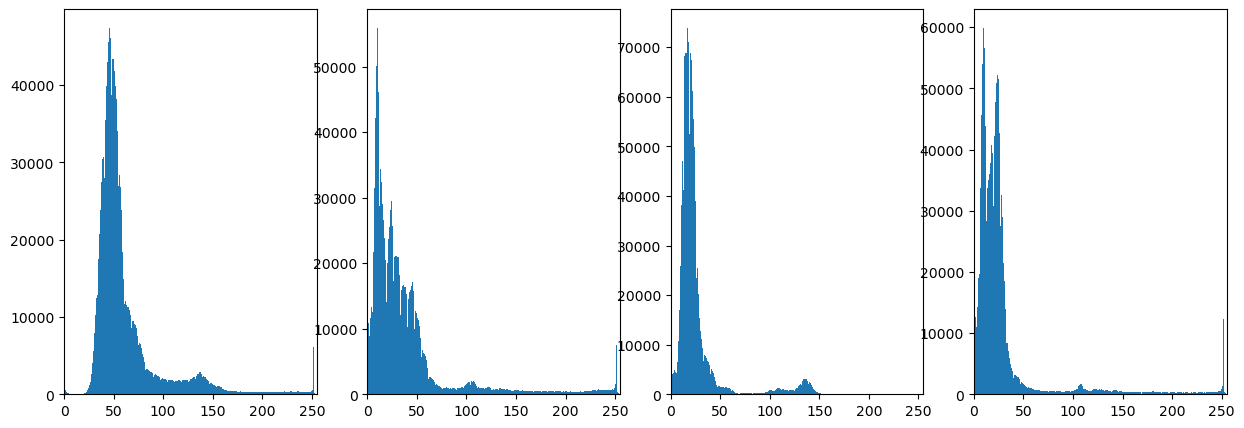

In [11]:
show_histograms(example_images_path, example_images_num_clean)

#### Let's look at the histogram of overexposed images

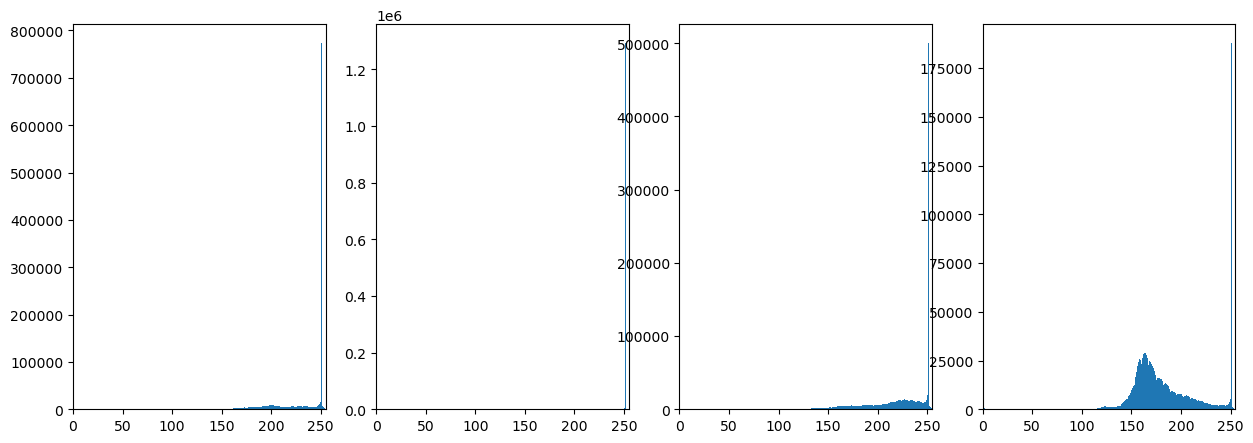

In [12]:
show_histograms(example_images_path, example_images_num_overexposed)

#### Let's look at the histogram of underexposed images

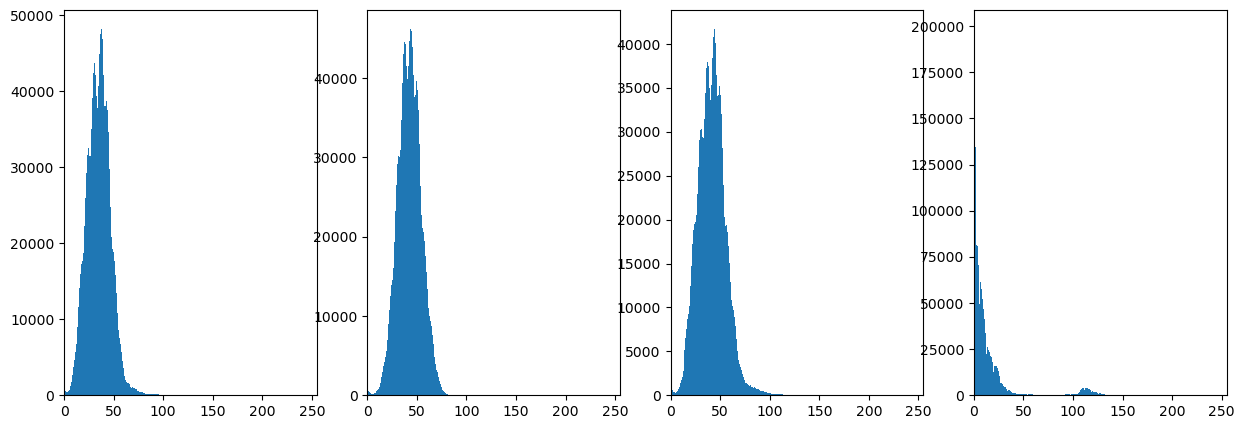

In [13]:
show_histograms(example_images_path, example_images_num_underexposed)

#### Let's look at the histogram of no Electric Arc images

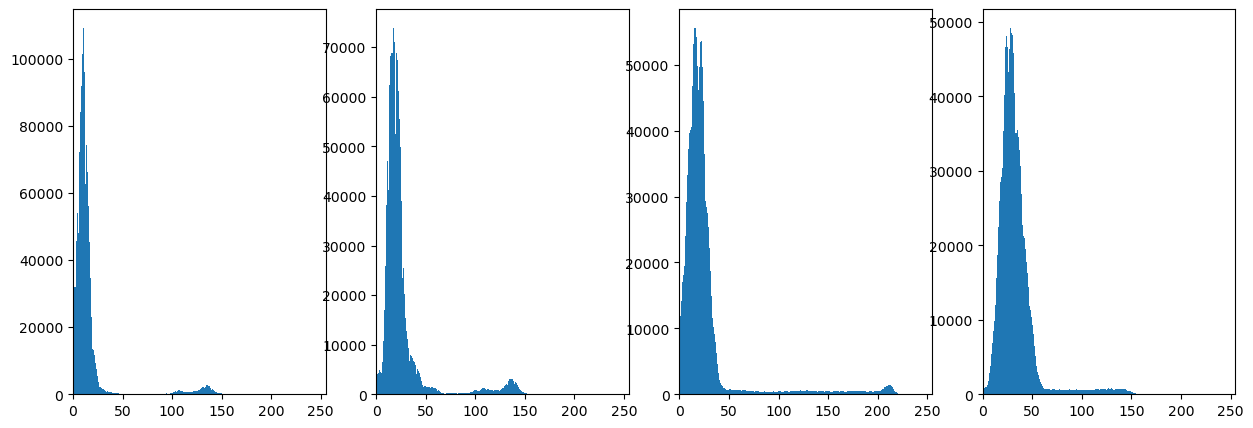

In [14]:
show_histograms(example_images_path, example_images_num_noElectricArc)

#### Let's look at the histogram of gas folk images

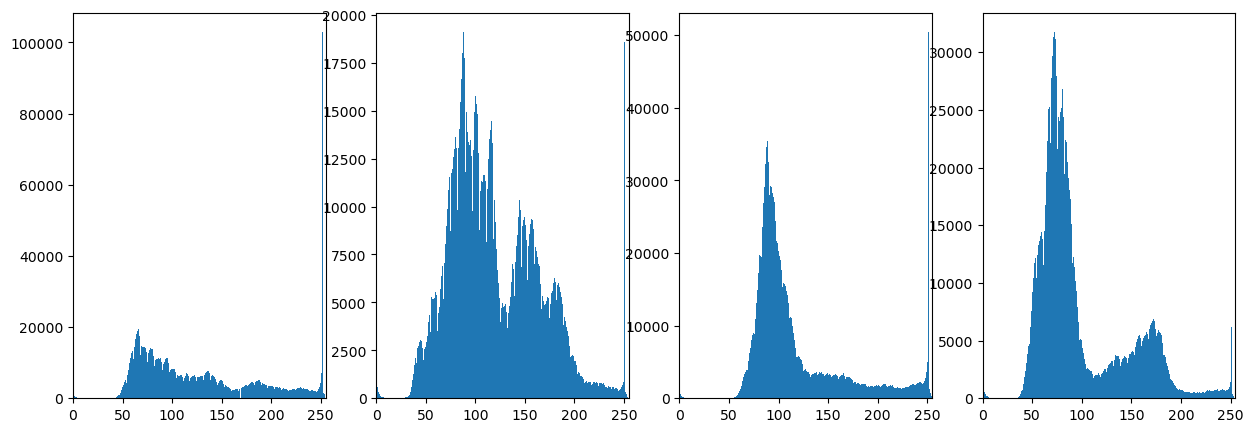

In [15]:
show_histograms(example_images_path, example_images_num_unsauber)

Durch die obigen fünf Analysegruppen, um einige Schlussfolgerungen zu ziehen.
#### Schwierigkeiten bei der Bilderkennung:
Bilder scheinen nicht genau Graustufen zu sein und anhand von Histogrammen weniger gut erkennen. Viele dunkle Bilder, aber kaum welche die komplett “schwarz” sind

Klassen | Verarbeitungsverfahren| Beschreibung  | Schwierigkeiten
---| ---| ---|---|
1.Mit Lichtbogen  |Beibehalten| Lichtbogen,Schweißbad, die erkennbar | **Schwierig** von Bildern zu unterscheiden, die von Gaswolken verdeckt werden 
2.Ohne Lichtbogen |Beibehalten|Nur Schweißbad erkennbar | **Schwierig** von unterbelichteten Bildern zu unterscheiden
3.Überlichtete    |Löschen    |Ganz Bild weiß sein      | Überbelichtete Bilder lassen sich anhand **von Histogrammen gut** filtern
4.Unterlichtete   |Löschen    |Ganz Bild schwarz sein   | Gleich wie Ohne Lichtbogen
5.Unsauber  Bilder|Löschen    |Gasvolke, Bildrauschen, Lokale Überlichtung| Gleich wie Mit Lichtbogen

#### Zusätzliche Parameter
Die Hauptquelle der aktuellen Analyse ist das Histogramm des Bildes. Gegenwärtig ist es schwierig, mindestens fünf Arten von Bildern durch einen einzigen Parameter (den Durchschnittswert des Histogramms) zu unterscheiden. Es werden also neue Parameter eingeführt. Dann werden weitere Informationen basierend auf dem Histogramm erweitert. Wie Beispiel: Varianz, Entropie.

> **Varianz:**  Misst die Abweichung der Daten um ihren Mittelwert. Ein Streuungsmaß, welches die Verteilung von Werten um den Mittelwert kennzeichnet.

> **Entropie:** Eine Zunahme der Entropie bedeutet eine Zunahme der Unordnung im System.

> **Prozent der Weißen Flecke:** Helligkeit als Prozentsatz des gesamten Bildes.



#### Example: 
Hier haben wir zehn Bilder für jede Kategorie ausgewählt. Dann werden die Daten tabelliert.





<div style="display:flex">
    InOrdnung:
     <div style="flex:1;padding-right:10px;">
          <img src="https://git.tu-berlin.de/xuhao123/bilder-dokument/-/raw/main/In_Ordnung.png" width="1200" height="500"/>
     </div>
   Unterlichtet:
     <div style="flex:1;padding-left:10px;">
          <img src="https://git.tu-berlin.de/xuhao123/bilder-dokument/-/raw/main/Unterlichtet.png" width="60%"/>
     </div>
</div>


<div style="display:flex">
     Überlichtet:
     <div style="flex:1;padding-left:10px;">
          <img src="https://git.tu-berlin.de/xuhao123/bilder-dokument/-/raw/main/Ueberlichtet.png" height="500"/>
     </div>
    Gasvolke(verdeckte):
     <div style="flex:1;padding-left:10px;">
          <img src="https://git.tu-berlin.de/xuhao123/bilder-dokument/-/raw/main/Schweissvolke_verdeckte_.png" width="60%"/>
     </div>
</div>



#### Trainieren die Kennzahlen:
Hier werden 5 Klassen definieren. Und durch Datensatz die Parametern genauer sein. Heutzutage ist muanuell die Parameter trainieren. Im Prinzip müssen die Parameter ausreichend oft trainiert werden, um eine genauere Filterung zu erhalten. Die aktuell ermittelten Parameter sind:

Klassen  | Parameterbereich 
---| ---|
1.Mit Lichtbogen  | 50 < Mittelgrauwert < 100 **&** Entropie > 6         
2.Ohne Lichtbogen | Mittelgrauwert < 50 **&** Varianz > 100 **&** Entropie < 6
3.Überlichtete    | Letzte Bin die größte Pixelzahl enthält          
4.Unterlichtete   | Mittelgrauwert < 50 **&** Varianz < 300 **&** Prozent der Weißen Flecke < 1%
5.Unsaubere Bilder| Nach verschiedenen Typen, wie z.B. Gasvolke: Varianz > 2500, Mittelwert > 70


### 02. Umsetzung


**Backbone des Systemes:**


    For image_path in Ordner:
        image = cv2.imread(image_path)
        if not is_greyscale(image): ___________________________1.Stufe: RGB Image to YUV Image
           image = RGB_to_YUV  
           mittelwerte =np.mean(image)
           
        if mittelwerte > 70:___________________________________2.Stufe: filtern heller Bild mit klarem Glanz:
           if is_overexposed(image) or is_unsauber(image):     
           - remove(image_path)-                               
           
           
        else:__________________________________________________3.Stufe: filtern dunkler Bild:
           if is_unterexposed(image):                          
           - remove(image_path)-
           


Durch parallel Weg wird die Rechenaufwand Signifikant reduziert.

In [16]:
from scipy.stats import entropy
from math import log, e
import pandas as pd

In [17]:
def is_overexposed(image, bins: int = 5):
    """
    We take a look at the histogram of the flattened picture (which is converted to greyscale first by taking the mean across the three color channels).
    Only if the last bin contains the largest number of pixels, we define the image to be overexposed.
    """
    return np.argmax(np.histogram(image, bins=bins)[0]) == bins - 1

Funktion "is_overexposed" mit einzel Bild Verfügbar:

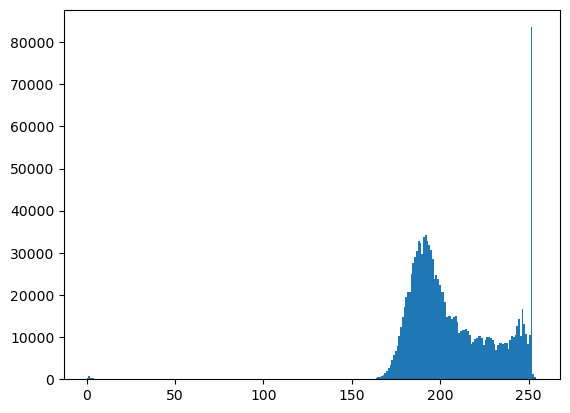

(207.88190307617188,
 633.3193996741998,
 False,
 array([  2333,    100,     37, 707065, 601185]))

In [18]:
os.chdir("/Users/xuhao/AUT/extracted_frames_no_duplicates")
image = cv2.imread('Sample2_vid4_0898.jpg')
grey = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
is_overexposed(image)
plt.hist(grey.ravel(),256,[0,255]); plt.show()
np.mean(grey),np.var(grey),is_overexposed(grey),(np.histogram(grey, bins=5)[0])[:]

In [19]:
def is_underexposed(image, bins: int = 5):
    """
    Only when the gray value of the image is less than 70 and the degree of scatter is very steep, 
    and most of the pixel(99%) values are in the first bin, is it recognized as underexposed
    """
    mean = np.mean(image)
    varianz = np.var(image)
    def white_spot_percentage(image,bins,i):      # Prozentsatz der hellen Pixelwerte im gesamten Bild
        return np.sum((np.histogram(image, bins=bins)[0])[i:])/(1024*1280)
    
    if 30<= mean <= 50:
        if varianz < 300 and white_spot_percentage(image,5,2) < 0.001: # Hellen Pixelwerte(100-250) besitzt kleiner als 0.1%
            return True
    elif mean <= 30:
        if varianz < 300 and white_spot_percentage(image,10,2) < 0.01: # Hellen Pixelwerte(75-250) besitzt kleiner als 1%
            return True
    return False


Funktion "is_underexposed" mit einzel Bild Verfügbar:

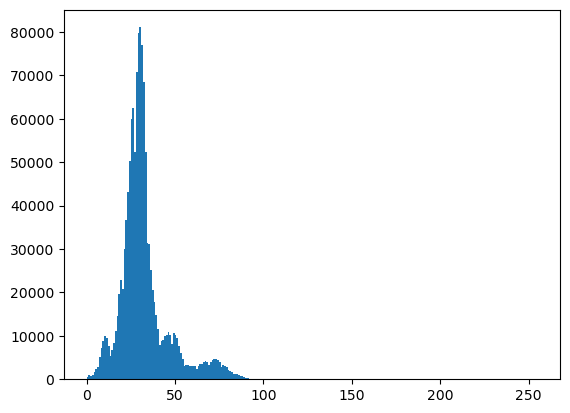

(32.23509292602539,
 220.6058908315136,
 True,
 array([1180547,  129378,     164,     124,     507]))

In [21]:
os.chdir("/Users/xuhao/AUT/extracted_frames_no_duplicates") # removed_frames_unterexposed,extracted_frames_no_duplicates
image_path = 'Sample2_vid2_0429.jpg' # Sample2_vid2_1579,(0,8%)Sample4_Video_220504-143400-meanderwall_1320
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.hist(image.ravel(),256,[0,255]); plt.show()
np.mean(image),np.var(image),is_underexposed(image), (np.histogram(image, bins=5)[0])[:]


In [31]:
def is_gasvolke(image):
    '''
    Only images with grayscale values between 100 and 150 have the possibility to filter
    '''
    mean = np.mean(image)
    varianz = np.var(image)
    if 180 >= mean >= 100:
        if varianz < 300:           #Exsample: Sample2_vid2_0631,Sample1_Video_220615-152743-STtoST_3_6_10_0356
            return True
        elif 1300 < varianz < 1500: #Nur Schweißbad wie Sample2_vid3_0391
            return False
        else:                       #Lokale Überbelichtet wie Sample2_vid3_0390
            return True
    elif 100 >= mean >= 70:
        if varianz < 200:           #Exsample: Sample2_vid2_0557
            return True
        elif varianz > 2500:        #Lokale Überbelichtet wie Sample1_Video_220615-152743-STtoST_3_6_10_0359
            return True
    elif mean >= 180:
        return True
    return False                     

Funktion "is_gasvolke" mit einzel Bild Verfügbar:

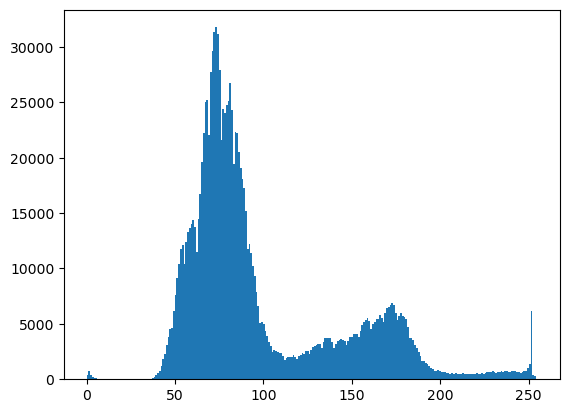

(99.3465461730957,
 2066.4178154483907,
 False,
 array([ 39646, 886103, 148015, 200127,  36829]))

In [34]:
os.chdir("/Users/xuhao/AUT/extracted_frames_no_duplicates") #removed_frames_unsauber,extracted_frames_no_duplicates
img = cv2.imread('Sample1_Video_220615-152743-STtoST_3_6_10_0112.jpg')          # Einzel Filename
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.hist(img.ravel(),256,[0,255]); plt.show()
np.mean(img),np.var(img),is_gasvolke(img),(np.histogram(img, bins=5)[0])[:]

Das folgende Programm wird gelaufen，**zur ”Data Cleaning“ der Durchführung.**

In [33]:
os.chdir("/Users/xuhao/AUT")
frames_dir = "./extracted_frames_no_duplicates/"
removed_frames_dir_over = "./removed_frames_overexposed/"
removed_frames_dir_volke = "./removed_frames_unsauber/"
removed_frames_dir_unter = "./removed_frames_unterexposed/"

removed_counter = 0
for image_path in tqdm(glob.iglob(f"{frames_dir}*.jpg")):
    image = cv2.imread(image_path)
    #if not is_greyscale(image_path):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mittelwerte =np.mean(image)
    if mittelwerte > 70:
        if is_overexposed(image):
            os.rename(image_path, f"{removed_frames_dir_over}{image_path.lstrip(frames_dir)}")
            removed_counter += 1
        elif is_gasvolke(image):
            os.rename(image_path, f"{removed_frames_dir_volke}{image_path.lstrip(frames_dir)}")
            removed_counter += 1
    else:
        if is_underexposed(image):
            os.rename(image_path, f"{removed_frames_dir_unter}{image_path.lstrip(frames_dir)}")
            removed_counter += 1
print(f"Number of frames that have been removed from the data: {removed_counter}")


27012it [08:21, 53.88it/s]

Number of frames that have been removed from the data: 2856


#### 3.Datensatz
Datensatz wird in [TUBcloud](https://tubcloud.tu-berlin.de/s/m2YseaFsLzxteoY?path=%2F06%20Daten) festgelegt. 
Name der Ordnern:  
> - Alle **sauber Bildern** speichern unten Ordner "extracted_frames_no_duplicates"
> - Alle **überbelichtete Bildern** speichern unten  Ordner "removed_frames_overexposed"
> - Alle **unterbelichtete Bildern** speichern unten  Ordner "removed_frames_unterexposed"
> - Alle **unsauber Bildern** speichern unten  Ordner "removed_frames_unsauber"

Workflow (Arbeitseinleitung): HTML und Notebook in [Github](https://git.tu-berlin.de/iat/aut-project-gefertec/-/tree/Bildvorverarbeitung).

#### 4. Resultat

**Kapitel 1.Videos zu Image per Frames**
> - Es wurde realisiert, das Video entsprechend den Frames in fortlaufende Bilder umzuwandeln
> - Die erzeugten fortlaufenden Bilder werden automatisch in einem Ordner mit dem Namen "extracted_frames_no_duplicates" abgelegt und hinzugefügt
> - Funktion zur Erkennung der echten Rahmennummer implementiert

**Kapitel 2.Data Clean**

Zeigt erst die Anzahl unterschiedlicher Bilder für diesen anfänglichen Datensatz an.

In [54]:
mid =0
low =0
high=0
morehigh=0
frames_dir = "../extracted_frames_no_duplicates/"
for image_path in tqdm(glob.iglob(f"{frames_dir}*.jpg")):
    image = cv2.imread(image_path)
    #if not is_greyscale(image_path):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mittelwerte =np.mean(image)
    if 150>mittelwerte > 100: 
        high += 1
    elif mittelwerte > 150:
        morehigh += 1
    elif mittelwerte < 50:
        low += 1
    else:
        mid += 1
print(f"Number of frames that have been grayvalue <50: {low}")
print(f"Number of frames that have been grayvalue 50-100: {mid}")
print(f"Number of frames that have been grayvalue 100-150: {morehigh}")
print(f"Number of frames that have been grayvalue >150: {high}")

27012it [03:54, 115.02it/s]

Number of frames that have been grayvalue <50: 20096
Number of frames that have been grayvalue 50-100: 5026
Number of frames that have been grayvalue 100-150: 367
Number of frames that have been grayvalue >150: 1523


Finally, "Data Clean" erreicht...
> + ... Automatisierter Prozess
> + ... Die aktuell angezeigten Bilder sind in drei Typen unterteilt: Überlichtet, Unterlichtet und Unsauber Bild
> + ... Ca. 93% der Bilder mit Grauwert von 0 bis 100. So außer der überbelichtete und unterbelichtet Bilder ist noch ca. 90 % Bilder machbar.
> + ... Ca. **10%** der Bilder wird rausgeschmissen. 


